<a href="https://colab.research.google.com/github/overgroove/samsung_lecture/blob/main/01_DL_TensorFlow_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DL basic process with Tensorflow**
- MLP 모델을 파이썬 딥러닝 프레임워크인 tensorflow를 활용하여 구현  
- 기본적인 코드 흐름 및 딥러닝에서 활용하는 여러가지 개념을 소개

## **module import**

In [ ]:
# 필요 모듈 import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

## **1. Data roading and set up**
- california_housing 데이터셋
- ML 및 DL 모델링 테스트에 활용하는 prediction 표준 데이터셋
- 미국 인구조사국(Census) 데이터를 기반으로 하고 있으며, 분석의 단위는 개별 주택이 아니라 집들이 모여 있는 특정 구역(평균 인구 약 1,425명 규모)

### **1.1 feature discriptions**
| 변수 이름 | 변수 명(한글) | 변수의 의미 및 특징 |
| :--- | :--- | :--- |
| **MedInc** | 소득수준 중앙값 | 10,000달러 단위 스케일링 |
| **HouseAge** | 해당 구역 주택 평균 연식 | 52년 최대값 한도설정 |
| **AveRooms** | 평균 방 갯수 | 소형, 대형 판단가능 |
| **AveBedrms** | 평균 침실 갯수 | 주택의 구조적 형태 유추 |
| **Population** | 총 인구수 | 구역의 크기나 밀도 대변 거시 지표 |
| **AveOccup** | 가구당 평균 구성원 수 | 값이 높다면 1인 가구 적음 |
| **Latitude** | 위도 | 지리적 좌표 |
| **Longitude** | 경도 | 해안가로부터 거리 계산 가능 |
| **target** | 평균 주택가격 | 10만 달러 단위로 스케일링 |



In [ ]:
# 데이터로딩 및 설명 출력
housing = fetch_california_housing()
print(housing['DESCR'])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [ ]:
# X, y 데이터 할당
X = pd.DataFrame(housing['data'], columns=housing['feature_names'])
y = housing['target']

In [ ]:
# 데이터 확인
# X, y 확인
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

## **2. MLP(Multi layer Perceptron)**
- **`MLP(Multi layer Perceptron)`** 는 사람의 신경을 본따 만든 머신러닝 알고리즘  
- 종속변수가 있어야 하는 **supervised** 모델이며 출력 구분에 따라 **prediction/classification 문제에 모두 사용**이 가능  
- 선형 분류기인 퍼셉트론의 한계를 극복하기 위해 퍼셉트론을 여러 층으로 쌓은 다층 퍼셉트론 구조를 갖는다.  
- 다차원의 비선형성 모델까지 표현이 가능하여 DNN 모델의 기초가 되는 모델
- 각 layer의 unit을 모두 연결하는 **FC(Fully Connected Layer)**구조

### **2.1 모델 구조**

<div align="center">
<img src="https://raw.githubusercontent.com/overgroove/ML_lecture_image_data/main/image/36.png">
</div>

- **input layer** : **설명변수(X)** 를 받아들이는(저장)하는 레이어  
- **hidden layer** : 연산 layer, **input과 output layer를 제외 한 모든 layer**는 hidden layer이다.  
- **output layer** : 출력 layer, 목적식 혹은 **예측/분류에 따라 출력 layer를 다르게** 설정하여 모델링.  
- **node(혹은 뉴런)** : layer에 포함 된 동그라미 하나, **perceptron**  
- **weight(가중치)** : node 와 node간 연결되어 있는 회색 화살표  

### **2.2 MLP unit 핵심 구조와 작동 원리**
<div align="center">
<img src="https://raw.githubusercontent.com/overgroove/ML_lecture_image_data/main/image/38.png">
</div>

# $$ \hat{y} = g(\sum_{i=1}^m x_iw_i)$$

### **2.3 activation functions(활성화함수)**
- 선형 결합 함수의 결과는 여전히 선형, 뉴런의 선형식 결과를 비선형 출력결과로 만들어주는 함수  
- 비선형 활성화 함수를 통해 모델은 복잡한 곡선 형태의 결정 경계를 만들 수 있으며, 현실 세계의 복잡한 데이터를 학습할 수 있습니다.
- 입력 데이터가 특정 임계값을 넘을 때 모델이 해당 정보를 '중요하다'고 판단하여 다음 층으로 전달할지 여부를 결정합니다.
- 출력값을 특정 범위(0 ~ 1 또는 -1 ~ 1)로 제한하여 수치적 안정성을 제공합니다.
- sigmoid, Tanh, ReLu와 같은 함수를 사용하여 출력결과값을 비선형으로 변환한다.
- 현대 딥러닝 모델의 경우 hidden layer에 사용하는 활성화 함수는 특별한 이유가 없으면 ReLU 함수의 변형을 사용하는 것이 일반적

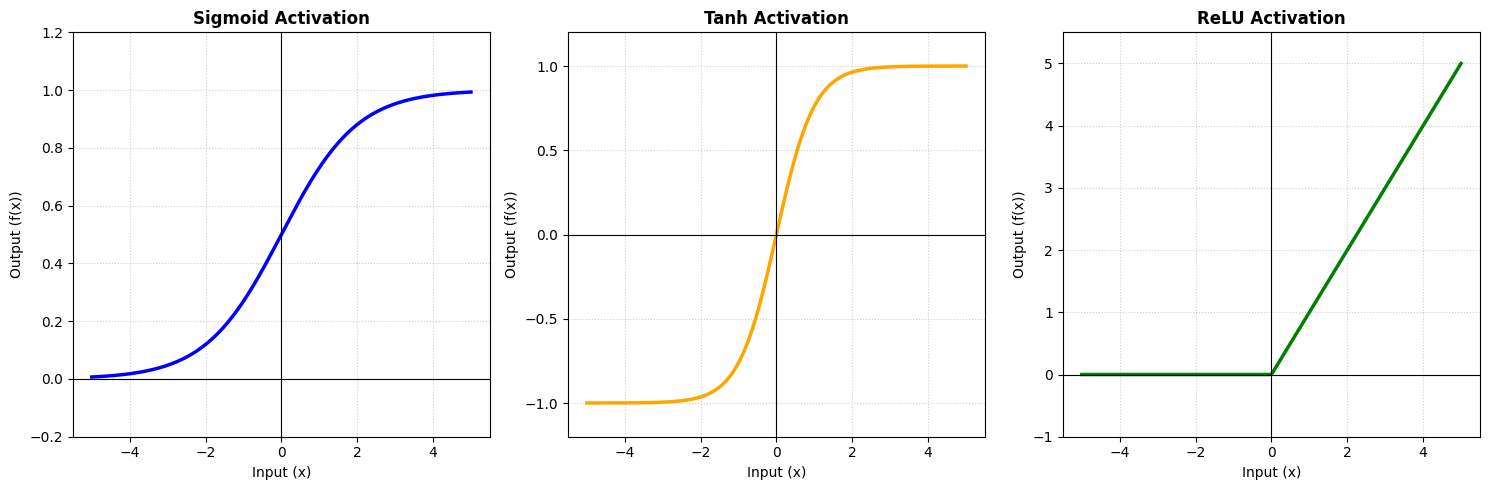

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def sigmoid(x: np.ndarray) -> np.ndarray:
    # Compute the sigmoid activation function
    return 1 / (1 + np.exp(-x))


def tanh(x: np.ndarray) -> np.ndarray:
    # Compute the hyperbolic tangent activation function
    return np.tanh(x)


def relu(x: np.ndarray) -> np.ndarray:
    # Compute the rectified linear unit activation function
    return np.maximum(0, x)


def plot_activation_subplots() -> None:
    # Generate input data space
    x: np.ndarray = np.linspace(-5, 5, 200)

    # Initialize a figure with 1 row and 3 columns of subplots
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # ----------------------------------------------------
    # Subplot 1: Sigmoid Function
    # ----------------------------------------------------
    axes[0].plot(x, sigmoid(x), color="blue", linewidth=2.5)
    axes[0].set_title("Sigmoid Activation", fontsize=12, fontweight="bold")
    axes[0].set_ylim(-0.2, 1.2)

    # ----------------------------------------------------
    # Subplot 2: Tanh Function
    # ----------------------------------------------------
    axes[1].plot(x, tanh(x), color="orange", linewidth=2.5)
    axes[1].set_title("Tanh Activation", fontsize=12, fontweight="bold")
    axes[1].set_ylim(-1.2, 1.2)

    # ----------------------------------------------------
    # Subplot 3: ReLU Function
    # ----------------------------------------------------
    axes[2].plot(x, relu(x), color="green", linewidth=2.5)
    axes[2].set_title("ReLU Activation", fontsize=12, fontweight="bold")
    axes[2].set_ylim(-1.0, 5.5)

    # Apply global decorations and styling to all subplots
    for ax in axes:
        ax.set_xlabel("Input (x)", fontsize=10)
        ax.set_ylabel("Output (f(x))", fontsize=10)
        ax.axhline(0, color="black", linewidth=0.8, linestyle="-")
        ax.axvline(0, color="black", linewidth=0.8, linestyle="-")
        ax.grid(True, linestyle=":", alpha=0.6)

    # Adjust layout to prevent overlapping labels
    plt.tight_layout()
    plt.show()


# Execute the subplot visualization function
plot_activation_subplots()

### **2.4 Forward Propagation(순전파) 작동방식**
<div align="center">
<img src="https://raw.githubusercontent.com/overgroove/ML_lecture_image_data/main/image/37.png">
</div>

hidden layer에 도달하는 값은 결국 X와 w의 선형 함수식으로 나타낼 수 있으며 벡터/매트릭스 연산으로 계산한다.  

# $$ z = w^Tx + b $$

### **2.5 back propagation(역전파)**
- **오차 역전파(Backpropagation)** 는 신경망이 예측값과 실제값 사이의 오차를 줄이기 위해, 출력층에서 입력층 방향으로 거슬러 올라가며 각 층의 가중치($w$)를 얼마나 수정해야 할지 계산하는 알고리즘입니다.
- chain rule을 활용 비용함수로부터 역방향으로 계산한다.  

- w2에 대한 가중치 업데이트
<img src="https://drive.google.com/uc?id=1NqlnOVAJCCDeWnk9r_5AK1x_b6Y_R62A">

- w2에 대한 비용함수의 편미분 식을 ($\hat{y}$에 대한 비용함수 편미분) X (w2에 대한 $\hat{y}$ 편미분)의 식으로 전개
<img src="https://drive.google.com/uc?id=1hOIW7EXow5gQab68QOo5HII2JAzhDg0u">


- 이후 w1에 대한 가중치 업데이트도 마찬가지 방법으로 편미분 chain rule 활용한다.
<img src="https://drive.google.com/uc?id=1WmhbYLibGLvxuxdLAKKREnkC9zkuedff">
<img src="https://drive.google.com/uc?id=1itEcg3mgJWvdH0n7odwHBRbm3ieg6cB_">

## **3. Tensorflow**
- **TensorFlow**는 구글이 개발한 오픈소스 기반의 세계적인 딥러닝 라이브러리
- Data Flow Graph 아키텍처를 기반으로 하여, CPU와 GPU는 물론 모바일 기기나 고성능 TPU 가속기까지 다양한 하드웨어 환경에서 복잡한 신경망 연산을 효율적으로 수행
- 고수준 API인 **Keras**를 표준으로 채택하면서 초보자도 직관적으로 모델을 설계하고 학습시킬 수 있는 대중성을 확보
- 대규모 프로덕션 환경까지 모델을 안정적으로 배포하고 관리할 수 있는 강력한 생태계(TensorBoard, TF Serving 등)를 제공

In [ ]:
# tensorflow import
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
# 코랩 GPU환경 구성 확인
!nvidia-smi

Thu Jun  4 15:26:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### **3.1 Keras modeling**

In [ ]:
# 모델 구조 생성(설계)
# 히든레이어 1개의 MLP 모델 구조 생성
tf.random.set_seed(42)

model1 = tf.keras.Sequential()
model1.add(layers.Input(shape=X_train.shape[1:]))
model1.add(layers.Dense(units=8, activation='relu', name='hidden'))
model1.add(layers.Dense(units=1))

model1.save('./simple_mlp.keras')

In [ ]:
# 모델 요약 출력
model1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden (Dense)                  │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)

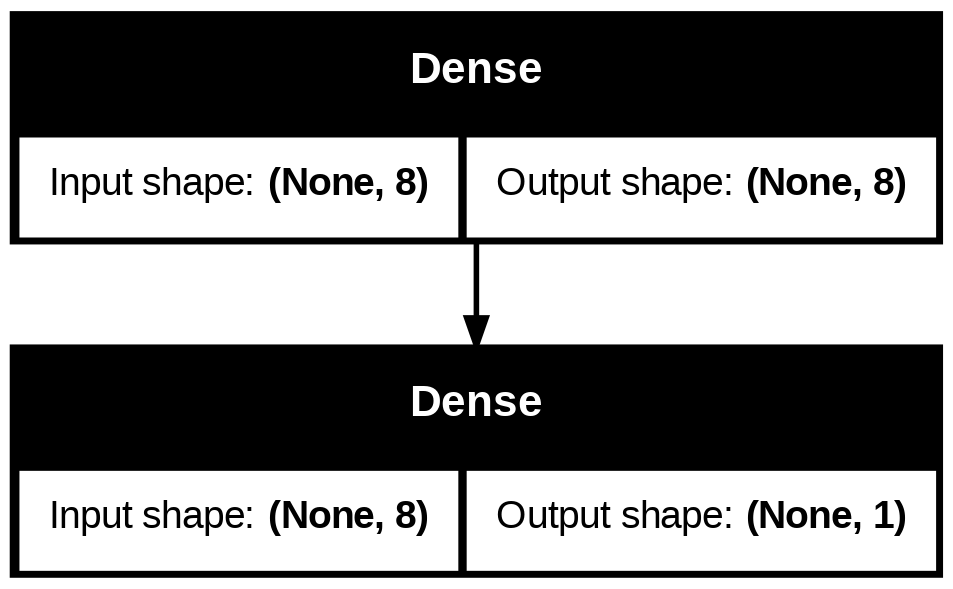

In [ ]:
# tf에서 제공하는 모델 구조 시각화
tf.keras.utils.plot_model(model1, show_shapes=True)

### **3.1.1 biases 추가 된 전체 모델 구조**
<div align="center">
  <img src="https://raw.githubusercontent.com/overgroove/ML_lecture_image_data/main/image/61.svg">
</div>

이미지출처 : 강사제작

### **3.2 complile(컴파일)**
- 설계한 딥러닝 모델 구조에 학습을 위한 구체적인 방법과 도구를 정의하고 모델에 연결(할당)하는 과정  
  
  - **optimazer(최적화 알고리즘)** : back propagation 과정 중 biases와 weights를 업데이트하는 방법론  
  - **loss(손실함수)** : 모델의 퍼포먼스를 계산하기 위한 방법론 ex) mse, categorical cross entrophy  
  - **metrics(평기지표)** : 모델 성능을 측정하기 위한 평가지표, mse, accuracy등

In [ ]:
# 모델 compile
model1.compile(loss='mse',
              optimizer='adam',
              metrics=['mse'])

## **3.3 fitting**
- 설계된 딥러닝 모델에 데이터를 학습시키는 과정  
  - **epochs** : 딥러닝 모델은 학습데이터를 설계 된 모델에 여러번 학습, 데이터 학습 횟수 설정 파라메터  
  - **validation_split** : 학습데이터의 일정 비율을 학습과정에서 검증용 데이터로 사용

In [ ]:
%%time
history = model1.fit(X_train, y_train, epochs=50, validation_split=0.2)

Epoch 1/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 409.0970 - mse: 409.0970 - val_loss: 23.6852 - val_mse: 23.6852
Epoch 2/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 16.7752 - mse: 16.7752 - val_loss: 10.0110 - val_mse: 10.0110
Epoch 3/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11.1793 - mse: 11.1793 - val_loss: 7.7348 - val_mse: 7.7348
Epoch 4/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.4721 - mse: 9.4721 - val_loss: 6.4701 - val_mse: 6.4701
Epoch 5/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8.1243 - mse: 8.1243 - val_loss: 5.2424 - val_mse: 5.2424
Epoch 6/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.9143 - mse: 6.9143 - val_loss: 4.2550 - val_mse: 4.2550
Epoch 7/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.7942 - mse: 5.7942 - val_loss: 3.4444 - val_mse: 3.4444
Epoch 8/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.8372 - mse: 4.8372 - val_loss: 2.7679 - val_mse: 2.7679
Epoch 9/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3

### **3.4 evaluate(모델평가)**
- 모델 피팅 과정을 history 객체에 저장 후 학습 이후 history 객체를 시각화하여 모델 학습 과정을 평가
- evaluate 메소드를 활용하여 complie과정중에 설정한 metric 함수 결과값 확인

In [ ]:
# 학습 과정 중 계산 된 loss, metric 확인
pd.DataFrame(history.history)

,loss,mse,val_loss,val_mse
0,38.223404,38.223404,6.326771,6.326771
1,5.383594,5.383594,4.059772,4.059772
2,3.199607,3.199607,2.632373,2.632373
3,2.032034,2.032034,1.764856,1.764856
4,1.397856,1.397856,1.317117,1.317117
5,1.153561,1.153561,0.970507,0.970507
6,0.946440,0.946440,0.870888,0.870888
7,0.913812,0.913812,0.915450,0.915450
8,0.968765,0.968765,0.943731,0.943731
9,0.970908,0.970908,0.918446,0.918446


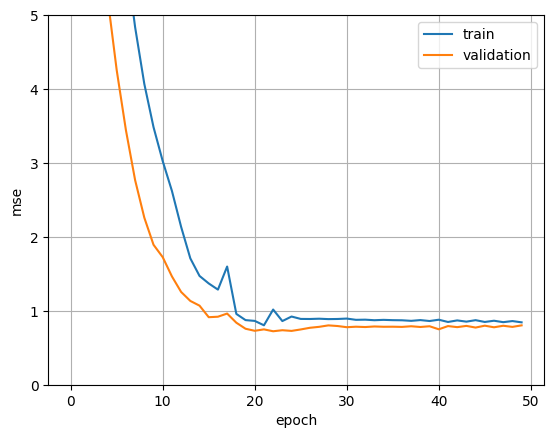

In [ ]:
# 학습데이터와 검증용 데이터의 학습곡선 시각화
def plot_learning_curves(history: tf.keras.callbacks.History) -> None:
    plt.plot(history.epoch, history.history['mse'])
    plt.plot(history.epoch, history.history['val_mse'])
    plt.xlabel('epoch')
    plt.ylabel('mse')
    plt.legend(['train', 'validation'])
    plt.grid(True)
    plt.gca().set_ylim(0, 5)
    plt.show()

plot_learning_curves(history)

In [ ]:
# evaluate
mse = model1.evaluate(X_test, y_test, verbose=2)

162/162 - 1s - 4ms/step - loss: 0.8164 - mse: 0.8164


### **3.5 predict**
- 학습이 완료 된 모델에 test데이터의 예측결과값을 확인
- MLops 관점으로는 실제 데이터 생성 시 모델에 실시간으로 전달하며 예측값을 확인하는 과정

In [ ]:
model1_pred = model1.predict(X_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
model1_pred

array([[0.64517754],
       [1.176378  ],
       [2.1286447 ],
       ...,
       [1.1880014 ],
       [2.1435525 ],
       [3.3265035 ]], dtype=float32)

### **3.6 순전파 계산 예측값 확인**

In [ ]:
X_input = X_test.iloc[0].values
hiddin_weights = model1.layers[0].get_weights()
out_weights = model1.layers[1].get_weights()
z1 = X_input @ hiddin_weights[0] + hiddin_weights[1]
a1 = np.maximum(0, z1)
z2 = a1 @ out_weights[0] + out_weights[1]

## **4. Activation function 변경 후 학습곡선 확인**
- model1의 hidden layer에 설정 되어 있는 activation function을 변경 후 학습곡선 확인
- 가장 대표적인 activation function인 sigmoid, tahn, relu 문자열 및 api로 전달

TensorFlow activation : https://www.tensorflow.org/api_docs/python/tf/keras/activations


In [ ]:
# 각 activation function api
activation_functions = {
    'sigmoid': tf.keras.activations.sigmoid,
    'tanh': tf.keras.activations.tanh,
    'relu': tf.keras.activations.relu
}

## **5. 레이어 깊이 변화에 따른 학습곡선 변화 확인 실습**
- 위에서 설계한 model1에 추가적으로 레이어를 쌓아 조금 더 복잡한 구조의 모델을 생성하고 학습
- 이후 model1과 학습곡선을 비교

In [ ]:
# model2 설계
tf.random.set_seed(42)

model2 = tf.keras.Sequential()
model2.add(layers.Input(shape=X_train.shape[1:]))
model2.add(layers.Dense(units=8, activation='sigmoid', name='hidden1'))
model2.add(layers.Dense(units=8, activation='sigmoid', name='hidden2'))
model2.add(layers.Dense(units=8, activation='sigmoid', name='hidden3'))
model2.add(layers.Dense(units=8, activation='sigmoid', name='hidden4'))
model2.add(layers.Dense(units=1))

# model2 complie
model2.compile(loss='mse',
              optimizer='adam',
              metrics=['mse'])

# model2.summary 확인
model2.summary()
model2.save('./deep_mlp.keras')

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden3 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden4 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 297 (1.16 KB)

 Trainable params: 297 (1.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# model2 fit
history2 = model2.fit(X_train, y_train, epochs=30, validation_split=0.2, callbacks=tensorboard_callback)

Epoch 1/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 3915.1738 - mse: 3915.1738 - val_loss: 2.0909 - val_mse: 2.0909
Epoch 2/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.9196 - mse: 1.9196 - val_loss: 1.6272 - val_mse: 1.6272
Epoch 3/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.4374 - mse: 1.4374 - val_loss: 1.4913 - val_mse: 1.4913
Epoch 4/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.3552 - mse: 1.3552 - val_loss: 1.4524 - val_mse: 1.4524
Epoch 5/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.3338 - mse: 1.3338 - val_loss: 1.4777 - val_mse: 1.4777
Epoch 6/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.3298 - mse: 1.3298 - val_loss: 1.4034 - val_mse: 1.4034
Epoch 7/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.3308 - mse: 1.3308 - val_loss: 1.4432 - val_mse: 1.4432
Epoch 8/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.3327 - mse: 1.3327 - val_loss: 1.4995 - val_mse: 1.4995
Epoch 9/30
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/ste

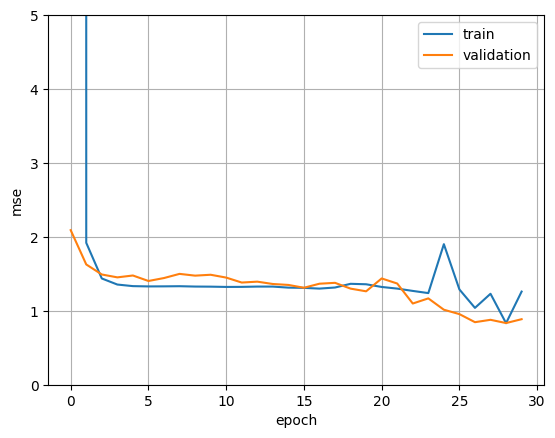

In [ ]:
# train data vs valiation data learning curve visualization
plot_learning_curves(history2)

## **5. Tensorboard**
- TensorBoard는 TensorFlow 생태계에서 제공하는 머신러닝 실험 및 시각화를 위한 전용 대시보드 도구
- 훈련 과정에서의 손실(Loss)과 평가지표(Metrics) 추이를 실시간 그래프로 모니터링
- 레이어별 가중치의 분포 및 복잡한 모델의 연산 그래프 구조를 시각적으로 명확하게 분석
- 딥러닝 모델의 그래디언트 소실이나 과적합 같은 디버깅 문제를 정량적으로 진단하고 해결책을 찾는 데 매우 유용

In [ ]:
# 로그 파일 설정 및 callback함수 설정
log_dir: str = (
    "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)
# Setting histogram_freq=1 will automatically log weight distributions every epoch
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

In [ ]:
# tensorboard 설정
%load_ext tensorboard
%tensorboard --logdir logs/fit